# Model D Development (Logistic Regression 2)

# 1. Load and Preprocess

In [5]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# 1. Load Data
file_path = '../data/processed/dataset_final.csv'

df = pd.read_csv(file_path)

# 2. Cleaning (Must match Model A exactly)
cols_to_drop = [
    'transaction_id', 'timestamp', 'customer_id', 
    'transaction_description', 'merchant_name', 'customer_support_note',
    'risk_category' 
]
df_clean = df.drop(columns=cols_to_drop, errors='ignore')

# 3. Encoding
df_encoded = pd.get_dummies(df_clean, drop_first=True)

# 4. Split
X = df_encoded.drop('is_fraud', axis=1)
y = df_encoded['is_fraud']

# 5. Train-Test Split (CRITICAL: Use random_state=42 to match Model A)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 6. Scaling (REQUIRED for Logistic Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("✅ Data loaded, cleaned, and SCALED for Logistic Regression.")
print(f"Training Shape: {X_train_scaled.shape}")

✅ Data loaded, cleaned, and SCALED for Logistic Regression.
Training Shape: (960, 40)


# 2. Train & Tune Logistic Regression

In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

# Setup Grid Search
param_grid = {
    'C': [0.01, 0.1, 1, 10],            # Regularization strength
    'solver': ['liblinear', 'lbfgs']    # Optimization algorithms
}

# Run Grid Search
grid_search = GridSearchCV(
    LogisticRegression(random_state=42, max_iter=1000),
    param_grid,
    cv=3,
    scoring='roc_auc',
    n_jobs=-1
)

print("Training Logistic Regression...")
grid_search.fit(X_train_scaled, y_train)

best_lr = grid_search.best_estimator_
print(f"✅ Best Parameters: {grid_search.best_params_}")

Training Logistic Regression...
✅ Best Parameters: {'C': 0.01, 'solver': 'lbfgs'}


# 3. Evaluate and Interpret

--- Model D (Logistic Regression) Final Evaluation ---
✅ Accuracy:  0.8458
✅ F1-Score:  0.4478
✅ ROC-AUC:   0.6820
✅ RMSE:      0.3632


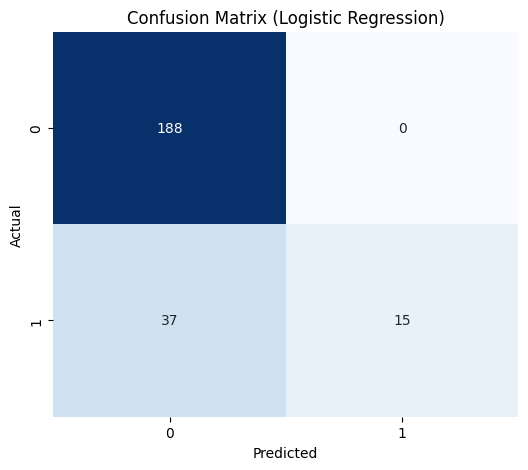

C:\Users\Nazrul Ikram\AppData\Local\Temp\ipykernel_9664\3060977670.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Coefficient', y='Feature', data=coef_df.head(10), palette='coolwarm')


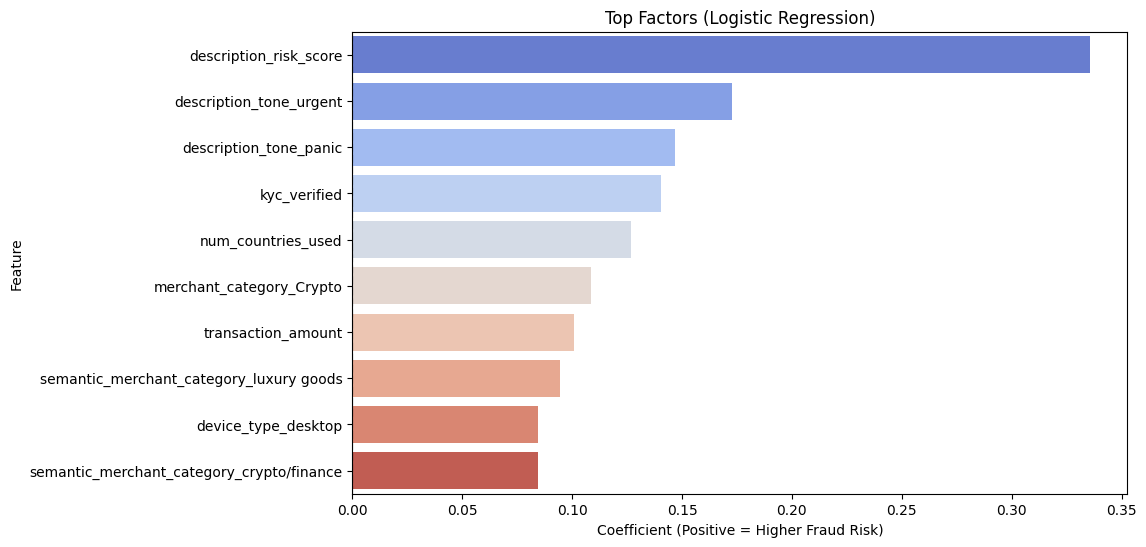

In [8]:
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score, mean_squared_error, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Predictions
y_pred = best_lr.predict(X_test_scaled)
y_prob = best_lr.predict_proba(X_test_scaled)[:, 1]

# 2. Calculate Required Metrics
acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)
# RMSE is technically for regression, but we can calculate it on probabilities (Brier Score)
rmse = np.sqrt(mean_squared_error(y_test, y_prob))

print("--- Model D (Logistic Regression) Final Evaluation ---")
print(f"✅ Accuracy:  {acc:.4f}")
print(f"✅ F1-Score:  {f1:.4f}")
print(f"✅ ROC-AUC:   {auc:.4f}")
print(f"✅ RMSE:      {rmse:.4f}")

# 3. Visual: Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix (Logistic Regression)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# 4. Feature Importance (Coefficients)
# We save this text to a variable so we can print it for the LLM later
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': best_lr.coef_[0]
}).sort_values(by='Coefficient', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Coefficient', y='Feature', data=coef_df.head(10), palette='coolwarm')
plt.title('Top Factors (Logistic Regression)')
plt.xlabel('Coefficient (Positive = Higher Fraud Risk)')
plt.axvline(x=0, color='black', linestyle='--')
plt.show()

In [9]:
# --- AUTO-GENERATED PROMPT FOR GEN-AI ---
# Run this cell, then COPY the output below and PASTE it into ChatGPT/Gemini.

print("📋 COPY THIS PROMPT INTO CHATGPT/GEMINI:\n")
print(f"I have trained a Logistic Regression model to detect fraud. Here are the results:")
print(f"- Accuracy: {acc:.4f}")
print(f"- F1-Score: {f1:.4f}")
print(f"- ROC-AUC: {auc:.4f}")
print(f"- RMSE: {rmse:.4f}")
print("\nThe top 5 most important features (and their weights) are:")
for index, row in coef_df.head(5).iterrows():
    print(f"- {row['Feature']}: {row['Coefficient']:.4f}")

print("\nBased on these results, please generate a 'Business Insight Summary' (approx 150 words).")
print("Explain what the metrics mean for a bank manager and interpret why these specific features are important predictors.")

📋 COPY THIS PROMPT INTO CHATGPT/GEMINI:

I have trained a Logistic Regression model to detect fraud. Here are the results:
- Accuracy: 0.8458
- F1-Score: 0.4478
- ROC-AUC: 0.6820
- RMSE: 0.3632

The top 5 most important features (and their weights) are:
- description_risk_score: 0.3359
- description_tone_urgent: 0.1728
- description_tone_panic: 0.1470
- kyc_verified: 0.1406
- num_countries_used: 0.1269

Based on these results, please generate a 'Business Insight Summary' (approx 150 words).
Explain what the metrics mean for a bank manager and interpret why these specific features are important predictors.


Business Insight Summary
Your fraud detection model achieves an accuracy of 84.6%, meaning it correctly classifies the majority of transactions. However, the F1-Score of 0.45 and ROC-AUC of 0.68 suggest the model struggles to balance precision and recall, likely missing a significant number of actual fraud cases or flagging too many legitimate ones (false positives). The RMSE of 0.36 indicates a moderate margin of error in its probability predictions.

The most predictive features reveal that textual context is critical. description_risk_score (0.34) is the strongest indicator, validating the use of risk scoring algorithms on transaction descriptions. Notably, emotional markers like description_tone_urgent (0.17) and description_tone_panic (0.15) are highly predictive, suggesting fraudsters often use emotionally charged language to bypass scrutiny. Additionally, operational metrics like kyc_verified (0.14) and num_countries_used (0.13) confirm that unverified accounts and cross-border activity remain key risk vectors.

Recommendation: While the model captures key behavioral patterns, its low F1-score suggests it should be used as a "flagging" system for human review rather than for automated blocking until recall improves.